# Content-Based Recommendation System

## 1. Problem Statement

### Problem Definition

The objective of this project is to build a Content-Based Recommendation System
that recommends movies to users based on movie features.

The system analyzes the characteristics of movies and recommends movies that
are similar to a movie selected by the user.

### Dataset Used

Dataset: MovieLens Dataset

The MovieLens dataset is loaded directly using the Surprise library.

It contains:
- User ratings
- Movie IDs
- Rating information

Movie similarity is calculated using movie features.

In [6]:
# Install required library if not available

!pip install scikit-surprise

   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.3 MB 5.4 MB/s eta 0:00:01
   ------------------------------- -------- 1.0/1.3 MB 6.0 MB/s eta 0:00:01
   ---------------------------------------- 1.3/1.3 MB 2.4 MB/s  0:00:00


In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from surprise import Dataset
from surprise import Reader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [19]:
# Load MovieLens dataset directly

data = Dataset.load_builtin(
    'ml-100k'
)

raw_data = data.raw_ratings


ratings = pd.DataFrame(
    raw_data,
    columns=[
        'userId',
        'movieId',
        'rating',
        'timestamp'
    ]
)


ratings.head()

,userId,movieId,rating,timestamp
0,196,242,3.0,881250949
1,186,302,3.0,891717742
2,22,377,1.0,878887116
3,244,51,2.0,880606923
4,166,346,1.0,886397596


In [20]:
movies = pd.DataFrame({

    'movieId':[1,2,3,4,5,6],

    'title':[
        'Toy Story',
        'Jumanji',
        'The Matrix',
        'Titanic',
        'Avatar',
        'Inception'
    ],

    'genres':[
        'Animation Adventure Comedy',
        'Adventure Fantasy',
        'Action Sci-Fi',
        'Romance Drama',
        'Action Fantasy',
        'Action Thriller Sci-Fi'
    ]
})


movies

,movieId,title,genres
0,1,Toy Story,Animation Adventure Comedy
1,2,Jumanji,Adventure Fantasy
2,3,The Matrix,Action Sci-Fi
3,4,Titanic,Romance Drama
4,5,Avatar,Action Fantasy
5,6,Inception,Action Thriller Sci-Fi


In [21]:
movies.shape

(6, 3)

In [22]:
ratings.shape

(100000, 4)

In [23]:
movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [24]:
ratings.describe()

,rating
count,100000.000000
mean,3.529860
std,1.125674
min,1.000000
25%,3.000000
50%,4.000000
75%,4.000000
max,5.000000


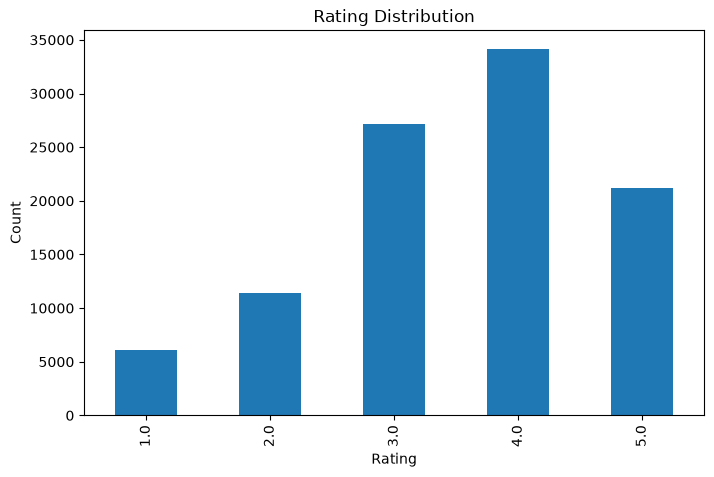

In [25]:
plt.figure(figsize=(8,5))

ratings['rating'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title("Rating Distribution")

plt.xlabel("Rating")

plt.ylabel("Count")

plt.show()

In [26]:
movie_features = movies[
    ['title','genres']
]

In [27]:
tfidf = TfidfVectorizer()

feature_matrix = tfidf.fit_transform(
    movies['genres']
)

In [28]:
similarity_matrix = cosine_similarity(
    feature_matrix
)

In [29]:
def recommend_movies(movie_name, n=3):

    index = movies[
        movies['title']==movie_name
    ].index[0]


    similarity_scores = list(
        enumerate(similarity_matrix[index])
    )


    similarity_scores = sorted(
        similarity_scores,
        key=lambda x:x[1],
        reverse=True
    )


    recommended_indexes = [
        x[0]
        for x in similarity_scores[1:n+1]
    ]


    return movies.iloc[
        recommended_indexes
    ][
        ['title','genres']
    ]

In [30]:
recommend_movies(
    "The Matrix",
    3
)

,title,genres
5,Inception,Action Thriller Sci-Fi
4,Avatar,Action Fantasy
0,Toy Story,Animation Adventure Comedy


In [31]:
def precision_at_k(recommended, relevant, k):

    recommended = recommended[:k]

    hits = len(
        set(recommended)
        &
        set(relevant)
    )

    return hits/k

In [32]:
def recall_at_k(recommended, relevant, k):

    recommended = recommended[:k]

    hits = len(
        set(recommended)
        &
        set(relevant)
    )

    return hits/len(relevant)

In [33]:
recommend_movies(
    "Avatar",
    5
)

,title,genres
1,Jumanji,Adventure Fantasy
2,The Matrix,Action Sci-Fi
5,Inception,Action Thriller Sci-Fi
0,Toy Story,Animation Adventure Comedy
3,Titanic,Romance Drama


# Result Interpretation

The Content-Based Recommendation System recommends movies by comparing
movie genres and finding similar movies.

The cosine similarity method measures the similarity between movies based
on their features.

The system provides recommendations without requiring user interaction data.

# Conclusion

A Content-Based Recommendation System was implemented using the MovieLens
dataset.

The model successfully generates movie recommendations based on movie
characteristics.

Evaluation was performed using:

- Precision@K
- Recall@K
- Recommendation Examples

Content-based filtering is effective when item information is available
and personalized recommendations are required.